# Tree node optimization
- In this notebook, we work with the pre-processed insurance data and we **optimize split** of one particular node.
- Namely for the smokers_yes == 1 node.
- The task is to **find optimal split** using the following 3 numerical features: **bmi, age and numer of children.**
- Intentionally, we are avoiding categorical variables as these are slightly more complicated (but not that much...)


## Data
Source: [https://www.kaggle.com/datasets/mirichoi0218/insurance]

Individual medical costs billed by health insurance

EDA: e.g [https://datauab.github.io/medical_insurance/]


In [1]:
import pandas as pd #data frames and other stuff
import numpy as np #arrays and statistical functions
import matplotlib.pyplot as plt #basic graphs
import pickle #load data in binary format

In [18]:
# import gdown
#In colab, you need to download the file first and save it locally
# file_id = '1ZHg2xs5ekH1XKzcvbJBkkqcHIl4J9mD9' #insurance.pkl
file_path = '../data/insurance_train_test.pkl'
# gdown.download('https://drive.google.com/uc?id={}'.format(file_id), file_path, quiet=False)

In [19]:
#Load the data
#for local installation / VM horizon
file_path = '../data/insurance_train_test.pkl'

#load data (already split into training and validation)
with open(file_path, "rb") as input_file:
    X_train,X_test, y_train, y_test = pickle.load(input_file)

#select subset for given node, i.e. filter only smoker_yes == 1
X = X_train.loc[X_train['smoker_yes'] == 1, ['age', 'bmi', 'children']]
y = y_train[X_train['smoker_yes'] == 1]

#Remove the original data
del X_train, y_train, X_test, y_test

print('---Features in X ---')
print(X.head())
print('---Target in y ---')
print(y.head())

---Features in X ---
     age   bmi  children
381   55  30.7         0
105   20  28.0         1
235   40  22.2         2
641   42  28.3         3
773   19  28.9         0
---Target in y ---
      charges
381  42303.69
105  17560.38
235  19444.27
641  32787.46
773  17748.51


## Suggested approach:
1) Define a function that calculates the sum of squares for given variable name and given split point.
2) Define a function that finds the best split point for given variable. Plot the sum of squares for each split point.
3) Define a function that finds the best split point for all variables and returns the best one.

In [20]:
#calculate sum of squares for given split
def ss(split_var_name, split_point, X, y):                                                                                                                             
    """                                                                                                                                                                
    This function calculates the sum of squares for given split                                                                                                        
    Inputs:                                                                                                                                                            
        split_var_name - name of the variable to split                                                                                                                 
        split_point - value to split the variable                                                                                                                      
        X - data frame with features                                                                                                                                   
        y - target variable                                                                                                                                            
    Output:                                                                                                                                                            
        sum of squares for both groups                                                                                                                                 
    """                                                                                                                                                                
    # Split the data into two groups based on the split point                                                                                                          
    left_mask = X[split_var_name] <= split_point                                                                                                                       
    right_mask = X[split_var_name] > split_point                                                                                                                       
                                                                                                                                                                    
    # Get the target values for each group                                                                                                                             
    left_y = y[left_mask]                                                                                                                                              
    right_y = y[right_mask]                                                                                                                                            
                                                                                                                                                                    
    # Calculate the mean for each group                                                                                                                                
    left_mean = left_y.mean() if len(left_y) > 0 else 0                                                                                                                
    right_mean = right_y.mean() if len(right_y) > 0 else 0                                                                                                             
                                                                                                                                                                    
    # Calculate the sum of squares for each group                                                                                                                      
    left_ss = ((left_y - left_mean) ** 2).sum() if len(left_y) > 0 else 0                                                                                              
    right_ss = ((right_y - right_mean) ** 2).sum() if len(right_y) > 0 else 0                                                                                          
                                                                                                                                                                    
    # Return the total sum of squares as a scalar value                                                                                                                
    return float(left_ss + right_ss)


In [21]:
def calculate_opt_ss(split_var_name, X, y):                                                                                                                            
    """                                                                                                                                                                
    This function calculates the optimal split point for a given variable                                                                                              
    Input:                                                                                                                                                             
        split_var_name: name of the variable to split on                                                                                                               
        X: data frame with features                                                                                                                                    
        y: target variable                                                                                                                                             
    Output:                                                                                                                                                            
        optimal split point,                                                                                                                                           
        optimal sum of squares,                                                                                                                                        
        unique potential split points, sum of squares for all potential split points                                                                                   
    """                                                                                                                                                                
    # Get unique observed values of split variable as the potential optimal split points                                                                               
    unique_values = sorted(X[split_var_name].unique())                                                                                                                 
                                                                                                                                                                    
    # Calculate ss for all potential split points                                                                                                                      
    ss_values = []                                                                                                                                                     
    for split_point in unique_values:                                                                                                                                  
        ss_value = ss(split_var_name, split_point, X, y)                                                                                                               
        ss_values.append(ss_value)                                                                                                                                     
                                                                                                                                                                    
    # Find the optimal split point and its corresponding sum of squares                                                                                                
    min_ss_index = np.argmin(ss_values)                                                                                                                                
    opt_split = unique_values[min_ss_index]                                                                                                                            
    opt_ss_value = ss_values[min_ss_index]                                                                                                                             
                                                                                                                                                                    
    return opt_split, opt_ss_value, unique_values, ss_values


In [22]:
def draw_optimal_split(split_var_name, opt_split, unique_potential_split_points, ss_for_split_points, X, y):                                                           
    """                                                                                                                                                                
    This function draws the sum of squares for all potential split points and boxplot for optimal split                                                                
    Inputs:                                                                                                                                                            
        split_var_name: name of the variable to split on                                                                                                               
        opt_split: optimal split point (output of calculate_opt_ss)                                                                                                    
        unique_potential_split_points: unique potential split points (output of calculate_opt_ss)                                                                      
        ss_for_split_points: sum of squares for all potential split points (output of calculate_opt_ss)                                                                
        X: data frame with features                                                                                                                                    
        y: target variable                                                                                                                                             
    Output: None                                                                                                                                                       
    """                                                                                                                                                                
    # Draw chart ss for all split points                                                                                                                               
    plt.figure(figsize=(10, 6))                                                                                                                                        
    plt.plot(unique_potential_split_points, ss_for_split_points, 'o-')                                                                                                 
    plt.axvline(x=opt_split, color='r', linestyle='--')                                                                                                                
    plt.title(f'Sum of Squares for Different Split Points of {split_var_name}')                                                                                        
    plt.xlabel(split_var_name)                                                                                                                                         
    plt.ylabel('Sum of Squares')                                                                                                                                       
    plt.grid(True)                                                                                                                                                     
    plt.show()                                                                                                                                                         
                                                                                                                                                                    
    # Draw a boxplot after optimal split                                                                                                                               
    plt.figure(plt.gcf().number+1)  # switch to next figure                                                                                                            
    plt.boxplot([y[X[split_var_name]<=opt_split].values.ravel(),                                                                                                       
                y[X[split_var_name]>opt_split].values.ravel()],                                                                                                       
                showmeans=True)                                                                                                                                        
    # Add x labels                                                                                                                                                     
    plt.xticks([1, 2], [f'{split_var_name}<={opt_split}', f'{split_var_name}>{opt_split}'])                                                                            
    plt.title(label=split_var_name)                                                                                                                                    
    plt.ylabel('charges')                                                                                                                                              
    plt.show() 

In [23]:
def find_best_split(X, y, variables=None):                                                                                                                             
    """                                                                                                                                                                
    This function finds the best split point across all variables                                                                                                      
    Inputs:                                                                                                                                                            
        X: data frame with features                                                                                                                                    
        y: target variable                                                                                                                                             
        variables: list of variable names to consider (default: all variables in X)                                                                                    
    Output:                                                                                                                                                            
        best variable name, best split point, best sum of squares                                                                                                      
    """                                                                                                                                                                
    if variables is None:                                                                                                                                              
        variables = X.columns                                                                                                                                          
                                                                                                                                                                    
    best_var = None                                                                                                                                                    
    best_split = None                                                                                                                                                  
    best_ss = float('inf')                                                                                                                                             
                                                                                                                                                                    
    for var in variables:                                                                                                                                              
        opt_split, opt_ss, _, _ = calculate_opt_ss(var, X, y)                                                                                                          
                                                                                                                                                                    
        # Ensure opt_ss is a scalar                                                                                                                                    
        if isinstance(opt_ss, (pd.Series, np.ndarray)):                                                                                                                
            opt_ss = float(opt_ss)                                                                                                                                     
                                                                                                                                                                    
        if opt_ss < best_ss:                                                                                                                                           
            best_var = var                                                                                                                                             
            best_split = opt_split                                                                                                                                     
            best_ss = opt_ss                                                                                                                                           
                                                                                                                                                                    
    return best_var, best_split, best_ss  

In [24]:
#calculate optimum for different variables
set_vars = ["bmi", "age", "children"] #try set of these variables

/tmp/ipykernel_18094/4094597969.py:30: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(left_ss + right_ss)


Variable: bmi, Optimal Split: 29.9, Sum of Squares: 6918145342.483118


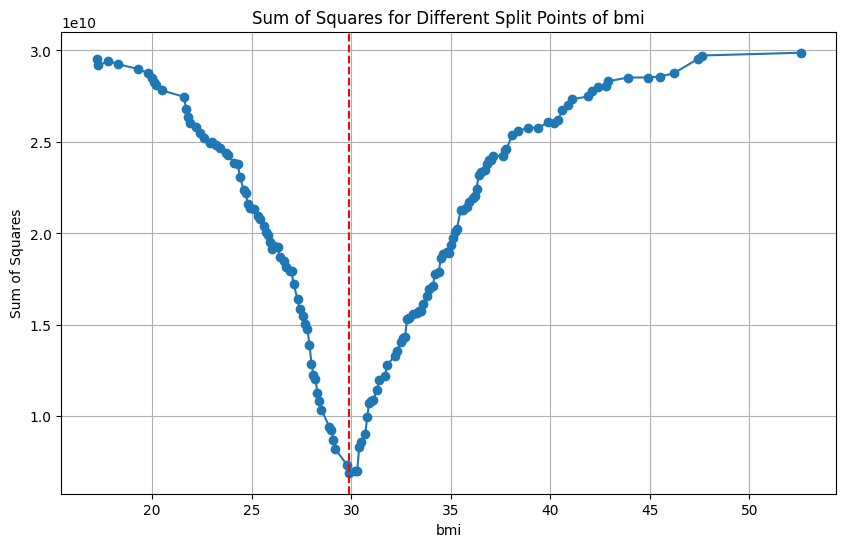

<Figure size 640x480 with 0 Axes>

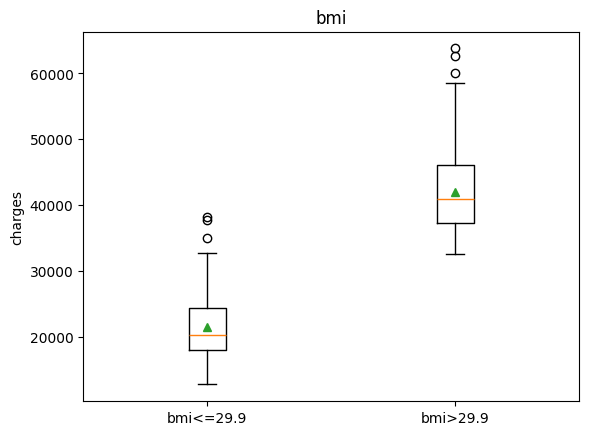

/tmp/ipykernel_18094/4094597969.py:30: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(left_ss + right_ss)


Variable: age, Optimal Split: 49, Sum of Squares: 26387216001.988846


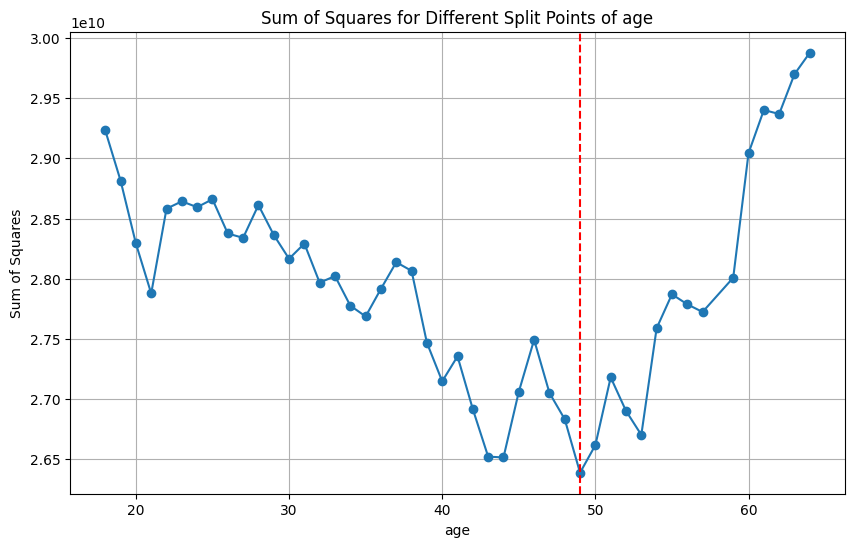

<Figure size 640x480 with 0 Axes>

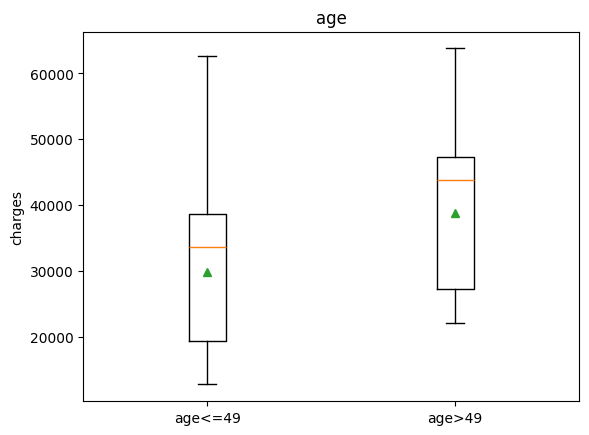

/tmp/ipykernel_18094/4094597969.py:30: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(left_ss + right_ss)


Variable: children, Optimal Split: 3, Sum of Squares: 29386685542.566036


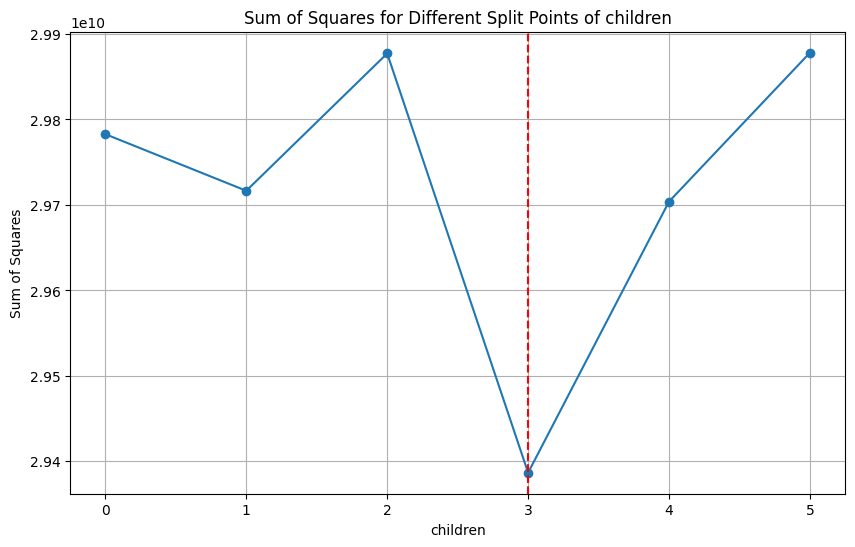

<Figure size 640x480 with 0 Axes>

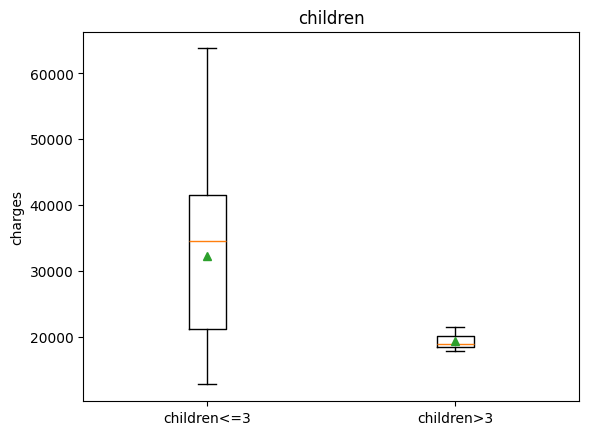

/tmp/ipykernel_18094/4094597969.py:30: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(left_ss + right_ss)



Best Variable: bmi, Best Split: 29.9, Best Sum of Squares: 6918145342.483118


In [25]:
# Find the best split for each variable and visualize                                                                                                                  
for var in set_vars:                                                                                                                                                   
    opt_split, opt_ss, unique_splits, ss_values = calculate_opt_ss(var, X, y)                                                                                          
    print(f"Variable: {var}, Optimal Split: {opt_split}, Sum of Squares: {opt_ss}")                                                                                    
    draw_optimal_split(var, opt_split, unique_splits, ss_values, X, y)                                                                                                 
                                                                                                                                                                    
# Find the best split across all variables                                                                                                                             
best_var, best_split, best_ss = find_best_split(X, y, set_vars)                                                                                                        
print(f"\nBest Variable: {best_var}, Best Split: {best_split}, Best Sum of Squares: {best_ss}") 

In [13]:
#calculate optimum for different variables
set_vars = ["bmi", "age", "children"] #try set of these variables

